#### Import required packages

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import RFECV

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


#### Import sample data and drop uneccessary columns

In [19]:
data_for_model = pd.read_pickle("data/abc_regression_modelling.p")
data_for_model.drop("customer_id", axis = 1, inplace = True)
print(data_for_model.columns)

Index(['distance_from_store', 'gender', 'credit_score',
       'customer_loyalty_score', 'total_sales', 'total_items',
       'transaction_count', 'product_area_count', 'average_basket_value'],
      dtype='object')


#### Shuffle data

In [20]:
data_for_model = shuffle(data_for_model, random_state = 42)

#### Dealing with missing values

In [23]:
data_for_model.isna().sum()
data_for_model.dropna(how = "any", inplace = True)

#### Dealing with outliers

In [31]:
outlier_investigation = data_for_model.describe()

outlier_columns = ["distance_from_store", "total_sales", "total_items"]

# Boxplot approach

for column in outlier_columns:

    lower_quartile = data_for_model[column].quantile(0.25)
    upper_quartile = data_for_model[column].quantile(0.75)
    iqr = upper_quartile - lower_quartile
    iqr_extended = iqr * 2
    min_border = lower_quartile - iqr_extended
    max_border = upper_quartile + iqr_extended

    outliers = data_for_model[(data_for_model[column] < min_border) | (data_for_model[column] > max_border)]
    print(f"{len(outliers)} outliers detected in column {column}")

    data_for_model.drop(outliers.index, inplace = True)

2 outliers detected in column distance_from_store
23 outliers detected in column total_sales
0 outliers detected in column total_items


#### Split Input variables and Output variables

In [32]:
X = data_for_model.drop(["customer_loyalty_score"], axis = 1)
y = data_for_model["customer_loyalty_score"]

#### Split out training and test sets

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Dealing with categorical variables

In [ ]:
categorical_vars = ["gender"]

one_hot_encoder = OneHotEncoder(sparse_output = False, drop = "first")

X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop = True), X_train_encoded.reset_index(drop = True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop = True), X_test_encoded.reset_index(drop = True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [41]:
print(X_train)

     distance_from_store  credit_score  total_sales  total_items  \
0                   0.19          0.57      1096.96          202   
1                   0.39          0.43       933.39          220   
2                   2.27          0.49      1506.49          281   
3                   3.10          0.59       330.79           81   
4                   0.07          0.53      2053.04          210   
..                   ...           ...          ...          ...   
290                 1.02          0.64      2490.66          263   
291                 0.66          0.45      3183.80          285   
292                 2.60          0.48      1815.22          306   
293                 1.81          0.54      1208.05          272   
294                 2.94          0.62      2397.63          282   

     transaction_count  product_area_count  average_basket_value  gender_M  
0                   53                   5             20.697358       1.0  
1                   51       

#### Feature Selection

In [42]:
regressor = LinearRegression()
feature_selector = RFECV(regressor)

fit = feature_selector.fit(X_train, y_train)

optimal_feature_count = feature_selector.n_features_
print(f"Optimal number of features : {optimal_feature_count}")

Optimal number of features : 8


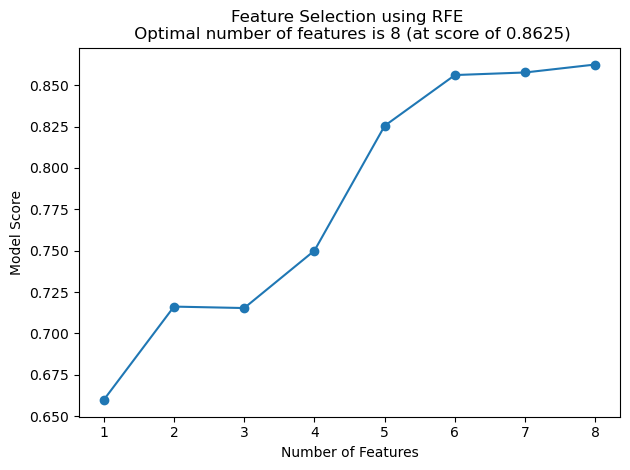

In [43]:
X_train = X_train.loc[:, feature_selector.get_support()]
X_test = X_test.loc[:, feature_selector.get_support()]

plt.plot(range(1, len(fit.cv_results_['mean_test_score']) + 1), fit.cv_results_['mean_test_score'], marker = "o")
plt.ylabel("Model Score")
plt.xlabel("Number of Features")
plt.title(f"Feature Selection using RFE \n Optimal number of features is {optimal_feature_count} (at score of {round(max(fit.cv_results_['mean_test_score']),4)})")
plt.tight_layout()
plt.show()

#### Model Training

In [44]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Assessment

#### Predict on the test set

In [45]:
y_pred = regressor.predict(X_test)

#### Calculate R-squared

In [46]:
r_squared = r2_score(y_test, y_pred)
print(r_squared)

0.7805702910327399


#### Cross validation

In [47]:
cv = KFold(n_splits = 4, shuffle = True, random_state = 42)
cv_scores = cross_val_score(regressor, X_train, y_train, cv =cv, scoring = "r2")
cv_scores.mean()

np.float64(0.8532327536589751)

#### Calculate adjusted R-squared

In [50]:
num_data_points, num_input_vars = X_test.shape
adjusted_r_squared = 1 - (1 - r_squared) * (num_data_points - 1) / (num_data_points - num_input_vars -1)
print(adjusted_r_squared)

0.7535635576213848


#### Extract model coefficients

In [55]:
coefficients = pd.DataFrame(regressor.coef_)
print(coefficients)

          0
0 -0.201232
1 -0.027697
2  0.000142
3  0.001002
4 -0.004842
5  0.061659
6 -0.003971
7 -0.013393


In [58]:
input_variable_names = pd.DataFrame(X_train.columns)
summary_stats = pd.concat([input_variable_names,coefficients], axis = 1)
summary_stats.columns = ["input_variable", "coefficient"]
print(summary_stats)

         input_variable  coefficient
0   distance_from_store    -0.201232
1          credit_score    -0.027697
2           total_sales     0.000142
3           total_items     0.001002
4     transaction_count    -0.004842
5    product_area_count     0.061659
6  average_basket_value    -0.003971
7              gender_M    -0.013393


#### Extract model intercept

In [59]:
regressor.intercept_

np.float64(0.5160974174646048)